In [2]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [4]:
from pathlib import Path

DATA_DIR = Path("../Data")

REGISTERED_FILE = DATA_DIR / "registered_voters.csv"
FIRST_ROUND_FILE = DATA_DIR / "first_round_may.csv"
NORTHGATE_FILE = DATA_DIR / "northgate_early_inperson.csv"
SOUTHFIELD_FILE = DATA_DIR / "southfield_early_inperson.xlsx"
MAIL_FILE = DATA_DIR / "mail_ballots.xlsx"

GEOJSON_FILE = Path("../precincts.geojson")

In [5]:
registered = pd.read_csv(REGISTERED_FILE)
first_round = pd.read_csv(FIRST_ROUND_FILE)
northgate = pd.read_csv(NORTHGATE_FILE)
southfield = pd.read_excel(SOUTHFIELD_FILE, header= 1)
mail = pd.read_excel(MAIL_FILE)

In [6]:
print("Registered:", registered.shape)
print("First Round:", first_round.shape)
print("Northgate:", northgate.shape)
print("Southfield:", southfield.shape)
print("Mail:", mail.shape)

Registered: (4012, 13)
First Round: (1169, 4)
Northgate: (123, 4)
Southfield: (97, 4)
Mail: (74, 4)


In [7]:
registered.head()

,SOS_VoterID,firstname,lastname,streetnumber,streetname,address,city,county,precinct_raw,party,sex,age,subdivision
0,7005758,Emma,Okafor,4545,Juniper St,4545 Juniper St,Lakeside,Southfield,15,DEM,M,55.0,NaN
1,7003258,Yuki,Nguyen,7348,Dogwood Dr,7348 Dogwood Dr,LAKESIDE,Northgate,10,NPA,M,35.0,STONEBRIAR SEC 7 (CPL)
2,7007413,Priya,Wilson,4387,Cypress Dr,4387 Cypress Dr,LAKESIDE,Northgate,20,U,F,24.0,STONEBRIAR SECTION 4
3,7006220,Jennifer,Davis,7152,Cypress Dr,7152 Cypress Dr,LAKESIDE,Southfield,15,LIB,M,29.0,OAK HOLLOW UNIT 5
4,7009799,David,Ali,5091,Juniper St,5091 Juniper St,LAKESIDE,Northgate,110,Independent,M,32.0,WILLOW CREEK PH 3


In [8]:
registered.describe()

,SOS_VoterID,streetnumber,precinct_raw,age
count,4.012000e+03,4012.000000,4012.000000,3871.000000
mean,7.004970e+06,5030.946411,84.371635,54.734694
std,2.865438e+03,2857.758045,83.216507,23.186685
min,7.000002e+06,100.000000,10.000000,0.000000
25%,7.002492e+06,2526.250000,20.000000,35.000000
50%,7.004954e+06,5089.000000,45.000000,54.000000
75%,7.007436e+06,7418.750000,130.000000,74.000000
max,7.009966e+06,9998.000000,264.000000,150.000000


In [9]:
first_round.head()

,voter_id,name,election,vote_date
0,7002115,Michael Johnson,2026 May General,2026-05-06
1,7002116,Jennifer Lee,2026 May General,2026-05-04
2,7006216,Yuki Martinez,2026 May General,2026-05-04
3,7002123,Jose Khan,2026 May General,2026-05-05
4,7006220,Jennifer Davis,2026 May General,2026-05-06


In [ ]:
northgate.head()

,CertificateNumber,VoterName,VoterAddress,VoteDate
0,7004160,"Anderson, Linda",4728 Cedar Ln,2026-06-03
1,7007236,"Park, Patricia",3840 Aspen Way,2026-06-04
2,7008259,"Anderson, Mei",1071 Pine Ct,2026-06-01
3,7000076,"Hernandez, Patricia",6690 Aspen Ln,06/03/2026
4,7009804,"Hernandez, James",721 Aspen Ct,2026-06-02


: 

: 

In [10]:
southfield.head()

,voter_guid,name,Muni,date_voted
0,7003136,Wei Brown,LAKESIDE,2026-06-03
1,7002115,Michael Johnson,LAKESIDE,2026-06-03
2,7007748,Emma Hernandez,LAKESIDE,2026-06-02
3,7003143,Carlos Singh,LAKESIDE,2026-06-01
4,7000080,Patricia Rodriguez,LAKESIDE,2026-06-04


In [11]:
mail.head()

,VUID,Voter,City State,Return Date
0,7004160,Linda Anderson,LAKESIDE TX,2026-06-02
1,7004800,Liam Lee,LAKESIDE TX,2026-06-02
2,7007233,Elizabeth Rossi,LAKESIDE TX,2026-06-01
3,7007748,Emma Hernandez,LAKESIDE TX,2026-06-02
4,7003783,Mei Singh,LAKESIDE TX,2026-06-02


In [12]:
for name, df in {
    "registered": registered,
    "first_round": first_round,
    "northgate": northgate,
    "southfield": southfield,
    "mail": mail
}.items():

    print(f"\n{name.upper()}")
    print(df.isnull().sum())


REGISTERED
SOS_VoterID       0
firstname         0
lastname          0
streetnumber      0
streetname        0
address           0
city              0
county            0
precinct_raw      0
party           297
sex             661
age             141
subdivision     801
dtype: int64

FIRST_ROUND
voter_id     0
name         0
election     0
vote_date    0
dtype: int64

NORTHGATE
CertificateNumber    0
VoterName            0
VoterAddress         0
VoteDate             0
dtype: int64

SOUTHFIELD
voter_guid    0
name          0
Muni          0
date_voted    0
dtype: int64

MAIL
VUID           0
Voter          0
City State     0
Return Date    0
dtype: int64


#### Missing values were present in party, sex, age, and subdivision fields. These fields were retained because they do not affect turnout calculations.


In [13]:
print("Registered duplicates:",registered["SOS_VoterID"].duplicated().sum())

print("First Round duplicates:",first_round["voter_id"].duplicated().sum())

print("Northgate duplicates:",northgate["CertificateNumber"].duplicated().sum())

print("Southfield duplicates:",southfield["voter_guid"].duplicated().sum())

print("Mail duplicates:",mail["VUID"].duplicated().sum())

Registered duplicates: 12
First Round duplicates: 0
Northgate duplicates: 0
Southfield duplicates: 0
Mail duplicates: 5


In [14]:
registered[registered["SOS_VoterID"].duplicated(keep=False)].sort_values("SOS_VoterID")

,SOS_VoterID,firstname,lastname,streetnumber,streetname,address,city,county,precinct_raw,party,sex,age,subdivision
2342,7001420,Elizabeth,Wilson,7931,Elm Trl,7931 Elm Trl,LAKESIDE,Northgate,220,DEM,NaN,24.0,STONEBRIAR SECTION 4
398,7001420,Elizabeth,Wilson,7931,Elm Trl,7931 Elm Trl,LAKESIDE,Northgate,220,DEM,NaN,24.0,STONEBRIAR SECTION 4
1,7003258,Yuki,Nguyen,7348,Dogwood Dr,7348 Dogwood Dr,LAKESIDE,Northgate,10,NPA,M,35.0,STONEBRIAR SEC 7 (CPL)
3181,7003258,Yuki,Nguyen,7348,Dogwood Dr,7348 Dogwood Dr,LAKESIDE,Northgate,10,NPA,M,35.0,STONEBRIAR SEC 7 (CPL)
776,7004914,Liam,Garcia,1468,Aspen Ct,1468 Aspen Ct,Lakeside,Northgate,45,DEM,U,66.0,WILLOW CREEK PH 3
517,7004914,Liam,Garcia,1468,Aspen Ct,1468 Aspen Ct,Lakeside,Northgate,45,DEM,U,66.0,WILLOW CREEK PH 3
1181,7005345,Aisha,Khan,9087,Sycamore Trl,9087 Sycamore Trl,LAKESIDE,Southfield,30,LIB,F,NaN,PRESTON RIDGE SECTION 2
3779,7005345,Aisha,Khan,9087,Sycamore Trl,9087 Sycamore Trl,LAKESIDE,Southfield,30,LIB,F,NaN,PRESTON RIDGE SECTION 2
1038,7006100,James,Nguyen,4613,Birch St,4613 Birch St,LAKESIDE,Southfield,264,REP,F,61.0,STONEBRIAR
524,7006100,James,Nguyen,4613,Birch St,4613 Birch St,LAKESIDE,Southfield,264,REP,F,61.0,STONEBRIAR


#### The registered voter file contained 12 duplicated voter records (6 duplicated voter IDs). All duplicated records were exact duplicates and were removed.

In [15]:
registered = registered.drop_duplicates(subset="SOS_VoterID")

print(registered.shape)

(4000, 13)


In [16]:
mail[mail["VUID"].duplicated(keep=False)].sort_values("VUID")

,VUID,Voter,City State,Return Date
33,7000127,Jennifer Rossi,LAKESIDE TX,2026-06-01
69,7000127,Jennifer Rossi,LAKESIDE TX,2026-06-01
31,7002045,David Patel,LAKESIDE TX,2026-06-02
72,7002045,David Patel,LAKESIDE TX,2026-06-02
53,7005280,John Rossi,LAKESIDE TX,2026-06-02
73,7005280,John Rossi,LAKESIDE TX,2026-06-02
13,7006100,James Nguyen,LAKESIDE TX,2026-06-01
70,7006100,James Nguyen,LAKESIDE TX,2026-06-01
51,7008479,Robert Wilson,LAKESIDE TX,2026-06-01
71,7008479,Robert Wilson,LAKESIDE TX,2026-06-01


In [17]:
mail = mail.drop_duplicates(subset="VUID")

print(mail.shape)

(69, 4)


#### Data Quality Findings

- Registered voter file contained 12 duplicate records.
- Duplicate voter records were exact duplicates and were removed.
- Mail ballot file contained 5 duplicate voter records.
- Duplicate mail ballot records were exact duplicates and were removed.
- Missing values were present in party, sex, age and subdivision fields.
- These fields were not required for turnout calculations and were retained.


In [18]:
registered["city"].value_counts()

city
LAKESIDE      1851
 LAKESIDE      629
Lakeside       580
lakeside       555
OAKDALE        141
PINEHURST      128
RIVERTON       116
Name: count, dtype: int64

In [19]:
registered["city"] = (registered["city"].str.strip().str.upper())

In [ ]:
registered["city"].value_counts()

city
LAKESIDE     3615
OAKDALE       141
PINEHURST     128
RIVERTON      116
Name: count, dtype: int64

: 

: 

: 

: 

In [20]:
registered["sex"].value_counts()

sex
M    1383
F    1323
U     635
Name: count, dtype: int64

In [21]:
registered["precinct_raw"].describe()

count    4000.000000
mean       84.395000
std        83.192432
min        10.000000
25%        20.000000
50%        45.000000
75%       130.000000
max       264.000000
Name: precinct_raw, dtype: float64

In [22]:
registered["party"].value_counts()


party
REP            945
DEM            906
U              334
LIB            323
NPA            315
Independent    300
IND            295
GRN            287
Name: count, dtype: int64

#### The party affiliation field contained inconsistent labeling for independent voters, recorded as both "IND" and "Independent". These values were standardized to a single category ("IND") to ensure consistency in grouping and turnout analysis.

In [23]:
registered["party"] = registered["party"].replace({"Independent": "IND"})

In [24]:
registered["party"].value_counts()

party
REP    945
DEM    906
IND    595
U      334
LIB    323
NPA    315
GRN    287
Name: count, dtype: int64

In [25]:
southfield["Muni"].value_counts()

Muni
LAKESIDE    97
Name: count, dtype: int64

#### Mail Ballots Dataset Cleaning

In [26]:
mail["City State"].value_counts()

City State
LAKESIDE TX    69
Name: count, dtype: int64

In [27]:
mail[["city", "state"]] = mail["City State"].str.split(" ", n=1, expand=True)
mail["city"] = mail["city"].str.strip().str.upper()
mail["state"] = mail["state"].str.strip().str.upper()

C:\Users\User\AppData\Local\Temp\ipykernel_17600\2027884914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mail[["city", "state"]] = mail["City State"].str.split(" ", n=1, expand=True)
C:\Users\User\AppData\Local\Temp\ipykernel_17600\2027884914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mail[["city", "state"]] = mail["City State"].str.split(" ", n=1, expand=True)
C:\Users\User\AppData\Local\Temp\ipykernel_17600\2027884914.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [28]:
mail = mail.drop(columns=["City State"])

In [29]:
mail.head()

,VUID,Voter,Return Date,city,state
0,7004160,Linda Anderson,2026-06-02,LAKESIDE,TX
1,7004800,Liam Lee,2026-06-02,LAKESIDE,TX
2,7007233,Elizabeth Rossi,2026-06-01,LAKESIDE,TX
3,7007748,Emma Hernandez,2026-06-02,LAKESIDE,TX
4,7003783,Mei Singh,2026-06-02,LAKESIDE,TX


#### Northgate Dataset Cleaning

In [30]:
northgate[["last_name", "first_name"]] = northgate["VoterName"].str.split(",", n=1, expand=True)

northgate["full_name"] = (
    northgate["first_name"].str.strip() + " " +
    northgate["last_name"].str.strip())

In [31]:
northgate = northgate.drop(columns=["VoterName","last_name", "first_name"])

In [32]:
northgate = northgate.rename(columns={"CertificateNumber": "voter_id"})

In [33]:
northgate.head(100)

,voter_id,VoterAddress,VoteDate,full_name
0,7004160,4728 Cedar Ln,2026-06-03,Linda Anderson
1,7007236,3840 Aspen Way,2026-06-04,Patricia Park
2,7008259,1071 Pine Ct,2026-06-01,Mei Anderson
3,7000076,6690 Aspen Ln,06/03/2026,Patricia Hernandez
4,7009804,721 Aspen Ct,2026-06-02,James Hernandez
...,...,...,...,...
95,7002001,4436 Elm St,06/03/2026,Linda Davis
96,7006101,5035 Dogwood Blvd,2026-06-04,Noah Mensah
97,7001494,3122 Hawthorn Trl,2026-06-03,Maria Wang
98,7004567,3893 Elm Blvd,2026-06-02,Hana Lee


In [35]:
northgate["VoteDate"].value_counts()

VoteDate
2026-06-01    28
2026-06-04    26
06/03/2026    26
2026-06-02    25
2026-06-03    18
Name: count, dtype: int64

In [36]:
northgate["VoteDate"] = pd.to_datetime(northgate["VoteDate"],format="mixed")

In [37]:
northgate["VoteDate"].value_counts()

VoteDate
2026-06-03    44
2026-06-01    28
2026-06-04    26
2026-06-02    25
Name: count, dtype: int64

### Date Standardization

The Northgate early-voting roster contained mixed date formats.
Most records used ISO format (`YYYY-MM-DD`), while 26 records
used `MM/DD/YYYY` format (`06/03/2026`).

All dates were standardized using `pd.to_datetime()`.
After standardization, the records were confirmed to fall
within the runoff voting period of June 1–4, 2026.

#### Southfield Ballots Dataset Cleaning

In [38]:
southfield = southfield.rename(columns={
    "voter_guid": "voter_id",
    "name": "full_name",
    "Muni": "city"})

southfield["city"] = southfield["city"].str.strip().str.upper()
southfield["date_voted"] = pd.to_datetime(southfield["date_voted"]).dt.date

In [39]:
southfield.head()

,voter_id,full_name,city,date_voted
0,7003136,Wei Brown,LAKESIDE,2026-06-03
1,7002115,Michael Johnson,LAKESIDE,2026-06-03
2,7007748,Emma Hernandez,LAKESIDE,2026-06-02
3,7003143,Carlos Singh,LAKESIDE,2026-06-01
4,7000080,Patricia Rodriguez,LAKESIDE,2026-06-04


In [41]:
datasets = {
    "registered": registered,
    "mail": mail,
    "northgate": northgate,
    "southfield": southfield,
    "first_round": first_round
}

for name, df in datasets.items():
    print("\n", name.upper())
    print(df.dtypes)


 REGISTERED
SOS_VoterID       int64
firstname        object
lastname         object
streetnumber      int64
streetname       object
address          object
city             object
county           object
precinct_raw      int64
party            object
sex              object
age             float64
subdivision      object
dtype: object

 MAIL
VUID            int64
Voter          object
Return Date    object
city           object
state          object
dtype: object

 NORTHGATE
voter_id                 int64
VoterAddress            object
VoteDate        datetime64[ns]
full_name               object
dtype: object

 SOUTHFIELD
voter_id       int64
full_name     object
city          object
date_voted    object
dtype: object

 FIRST_ROUND
voter_id      int64
name         object
election     object
vote_date    object
dtype: object


In [43]:
registered = registered.rename(
    columns={"SOS_VoterID": "voter_id"})

mail = mail.rename(
    columns={"VUID": "voter_id"})

In [44]:
first_round = first_round.rename(
    columns={"name": "full_name"})

mail = mail.rename(
    columns={"Voter": "full_name"})

In [49]:
first_round.head()

,voter_id,full_name,election,vote_date
0,7002115,Michael Johnson,2026 May General,2026-05-06
1,7002116,Jennifer Lee,2026 May General,2026-05-04
2,7006216,Yuki Martinez,2026 May General,2026-05-04
3,7002123,Jose Khan,2026 May General,2026-05-05
4,7006220,Jennifer Davis,2026 May General,2026-05-06


In [51]:
first_round["vote_date"] = pd.to_datetime(first_round["vote_date"])

southfield["date_voted"] = pd.to_datetime(southfield["date_voted"])

mail["Return Date"] = pd.to_datetime(mail["Return Date"])

In [52]:
northgate = northgate.rename(
    columns={"VoteDate": "vote_date"})

southfield = southfield.rename(
    columns={"date_voted": "vote_date"})

mail = mail.rename(
    columns={"Return Date": "vote_date"})

In [53]:
datasets = {
    "registered": registered,
    "mail": mail,
    "northgate": northgate,
    "southfield": southfield,
    "first_round": first_round
}

for name, df in datasets.items():
    print("\n", name.upper())
    print(df.dtypes)


 REGISTERED
voter_id          int64
firstname        object
lastname         object
streetnumber      int64
streetname       object
address          object
city             object
county           object
precinct_raw      int64
party            object
sex              object
age             float64
subdivision      object
dtype: object

 MAIL
voter_id              int64
full_name            object
vote_date    datetime64[ns]
city                 object
state                object
dtype: object

 NORTHGATE
voter_id                 int64
VoterAddress            object
vote_date       datetime64[ns]
full_name               object
dtype: object

 SOUTHFIELD
voter_id              int64
full_name            object
city                 object
vote_date    datetime64[ns]
dtype: object

 FIRST_ROUND
voter_id              int64
full_name            object
election             object
vote_date    datetime64[ns]
dtype: object


### Build the Unified Runoff Voter List

In [58]:


# Tag each source before combining
northgate["vote_method"] = "early_inperson"
southfield["vote_method"] = "early_inperson"
mail["vote_method"] = "mail"

northgate["county"] = "Northgate"
southfield["county"] = "Southfield"
mail["county"] = "unknown"  # mail ballots span both counties

# Standardize columns across all three before stacking
northgate_clean = northgate[["voter_id", "full_name", "vote_date", "vote_method", "county"]].copy()
southfield_clean = southfield[["voter_id", "full_name", "vote_date", "vote_method", "county"]].copy()
mail_clean = mail[["voter_id", "full_name", "vote_date", "vote_method", "county"]].copy()

# Stack them
runoff = pd.concat([northgate_clean, southfield_clean, mail_clean], ignore_index=True)

print("Before dedup:", runoff.shape)
print("Duplicate voter_ids:", runoff["voter_id"].duplicated().sum())

# Check who appears more than once
dupes = runoff[runoff["voter_id"].duplicated(keep=False)].sort_values("voter_id")
print("\nDuplicated voters across sources:")
print(dupes)

Before dedup: (289, 5)
Duplicate voter_ids: 13

Duplicated voters across sources:
     voter_id           full_name  vote_date     vote_method      county
18    7000130          Omar Smith 2026-06-03  early_inperson   Northgate
259   7000130          Omar Smith 2026-06-02            mail     unknown
26    7000184  Patricia Hernandez 2026-06-03  early_inperson   Northgate
269   7000184  Patricia Hernandez 2026-06-02            mail     unknown
258   7000388      Priya Anderson 2026-06-01            mail     unknown
187   7000388      Priya Anderson 2026-06-03  early_inperson  Southfield
280   7002223          Ama Nguyen 2026-06-02            mail     unknown
24    7002223          Ama Nguyen 2026-06-03  early_inperson   Northgate
215   7002594         Linda Smith 2026-06-01  early_inperson  Southfield
275   7002594         Linda Smith 2026-06-01            mail     unknown
152   7002763       Mateo Johnson 2026-06-01  early_inperson  Southfield
228   7002763       Mateo Johnson 2026-06-


#### 13 voters appear in both mail and in-person rosters.

In [61]:
# Keep in-person over mail when duplicated
# Sort so early_inperson comes first, then drop duplicate voter_ids keeping first
runoff_sorted = runoff.sort_values(
    "vote_method",
    key=lambda x: x.map({"early_inperson": 0, "mail": 1})
)

runoff_deduped = runoff_sorted.drop_duplicates(subset="voter_id", keep="first").copy()

print("After dedup:", runoff_deduped.shape)
print("Unique voters:", runoff_deduped["voter_id"].nunique())
print("\nVote method breakdown:")
print(runoff_deduped["vote_method"].value_counts())
print("\nCounty breakdown:")
print(runoff_deduped["county"].value_counts())

After dedup: (276, 5)
Unique voters: 276

Vote method breakdown:
vote_method
early_inperson    220
mail               56
Name: count, dtype: int64

County breakdown:
county
Northgate     123
Southfield     97
unknown        56
Name: count, dtype: int64


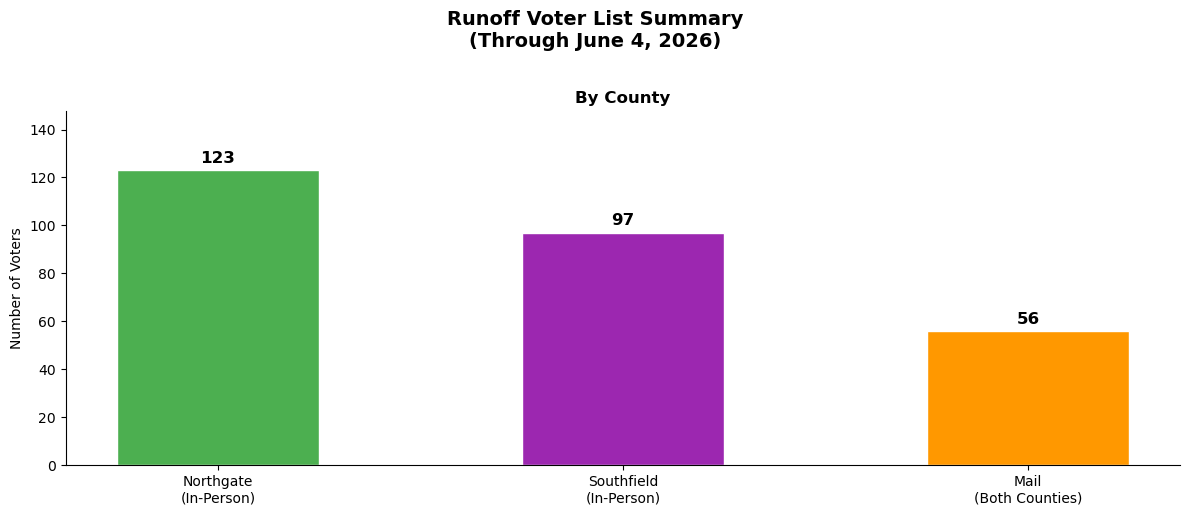

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(
    "Runoff Voter List Summary\n(Through June 4, 2026)",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

county_labels = ["Northgate\n(In-Person)", "Southfield\n(In-Person)", "Mail\n(Both Counties)"]
county_values = [123, 97, 56]
county_colors = ["#4CAF50", "#9C27B0", "#FF9800"]

ax.bar(county_labels, county_values, color=county_colors, edgecolor="white", width=0.5)
ax.set_title("By County", fontweight="bold")
ax.set_ylabel("Number of Voters")
ax.set_ylim(0, max(county_values) * 1.2)

for i, v in enumerate(county_values):
    ax.text(i, v + 3, str(v), ha="center", fontweight="bold", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [68]:
# ── Step 3: Precinct-Level Turnout Calculation ────────────────────────────────

# ── 3a: Filter registered voters to Lakeside only ────────────────────────────
print("City breakdown in registered voters:")
print(registered["city"].value_counts())

lakeside_registered = registered[registered["city"] == "LAKESIDE"].copy()

print(f"\nTotal registered voters:          {len(registered)}")
print(f"Lakeside registered voters:       {len(lakeside_registered)}")
print(f"Non-Lakeside voters excluded:     {len(registered) - len(lakeside_registered)}")

City breakdown in registered voters:
city
LAKESIDE     3615
OAKDALE       141
PINEHURST     128
RIVERTON      116
Name: count, dtype: int64

Total registered voters:          4000
Lakeside registered voters:       3615
Non-Lakeside voters excluded:     385


In [69]:
# ── 3b: Match runoff voters to registered voters to get precinct ──────────────

runoff_with_precinct = runoff_deduped.merge(
    lakeside_registered[["voter_id", "precinct_raw", "county"]],
    on="voter_id",
    how="left",
    suffixes=("_runoff", "_registered")
)

print("Runoff voters after merge:", runoff_with_precinct.shape)
print("\nHow many matched to a Lakeside registered voter:")
print(runoff_with_precinct["precinct_raw"].notna().value_counts())

# Check unmatched voters
unmatched = runoff_with_precinct[runoff_with_precinct["precinct_raw"].isna()]
print(f"\nUnmatched voters: {len(unmatched)}")
if len(unmatched) > 0:
    print(unmatched[["voter_id", "full_name", "vote_method", "county_runoff"]])

Runoff voters after merge: (276, 7)

How many matched to a Lakeside registered voter:
precinct_raw
True    276
Name: count, dtype: int64

Unmatched voters: 0


In [70]:
# ── 3c: Explore precinct_raw values and map to GeoJSON pctkey ─────────────────

print("Unique precinct_raw values in Lakeside registered voters:")
print(sorted(lakeside_registered["precinct_raw"].unique()))

print("\nPrecinct by county breakdown:")
print(lakeside_registered.groupby(["county", "precinct_raw"]).size().reset_index(name="registered_count"))

print("\nGeoJSON pctkey values:")
import json
with open("../precincts.geojson") as f:
    geojson = json.load(f)
    
pctkeys = [f["properties"]["pctkey"] for f in geojson["features"]]
print(sorted(pctkeys))

Unique precinct_raw values in Lakeside registered voters:
[10, 15, 20, 30, 45, 75, 110, 120, 130, 210, 220, 253, 264]

Precinct by county breakdown:
        county  precinct_raw  registered_count
0    Northgate            10               421
1    Northgate            20               308
2    Northgate            30               379
3    Northgate            45               325
4    Northgate           110               241
5    Northgate           220               127
6    Northgate           253               228
7   Southfield            15               426
8   Southfield            30               262
9   Southfield            75               134
10  Southfield           120               133
11  Southfield           130               261
12  Southfield           210               276
13  Southfield           264                94

GeoJSON pctkey values:
['700010', '700020', '700030', '700045', '700110', '700220', '880015', '880030', '880075', '880120', '880130', '880210']


In [ ]:
# ── Check voters in precincts missing from GeoJSON ───────────────────────────

missing_precincts = runoff_with_precinct[runoff_with_precinct["precinct_raw"].isin([253, 264])]

print("Runoff voters in precincts missing from GeoJSON:")
print(missing_precincts[["voter_id", "full_name", "precinct_raw", "county_registered"]])
print(f"\nTotal affected: {len(missing_precincts)}")
print(f"\nRegistered voters in precinct 253: 228")
print(f"Registered voters in precinct 264: 94")

Runoff voters in precincts missing from GeoJSON:
     voter_id          full_name  precinct_raw county_registered
0     7004160     Linda Anderson           253         Northgate
15    7005335     Michael Nguyen           264        Southfield
35    7006705       Aisha Thomas           253         Northgate
36    7008242          Linda Ali           253         Northgate
44    7001624     Priya Martinez           264        Southfield
54    7007920     Jennifer Cohen           264        Southfield
76    7001573         Kofi Rossi           264        Southfield
77    7009775        Linda Singh           264        Southfield
101   7006015     James Martinez           264        Southfield
111   7004599         Kofi Cohen           253         Northgate
125   7003837        Yuki Thomas           253         Northgate
161   7003744         Ama Thomas           253         Northgate
164   7009836       Michael Park           253         Northgate
169   7007591         Fatima Ali         

In [72]:
# ── 3d: Build precinct key mapping ───────────────────────────────────────────

precinct_map = {
    # Northgate → 700xxx
    ("Northgate", 10):  "700010",
    ("Northgate", 20):  "700020",
    ("Northgate", 30):  "700030",
    ("Northgate", 45):  "700045",
    ("Northgate", 110): "700110",
    ("Northgate", 220): "700220",
    ("Northgate", 253): "NO_GEOMETRY",  # missing from GeoJSON

    # Southfield → 880xxx
    ("Southfield", 15):  "880015",
    ("Southfield", 30):  "880030",
    ("Southfield", 75):  "880075",
    ("Southfield", 120): "880120",
    ("Southfield", 130): "880130",
    ("Southfield", 210): "880210",
    ("Southfield", 264): "NO_GEOMETRY",  # missing from GeoJSON
}

# Apply mapping to registered voters
lakeside_registered["pctkey"] = lakeside_registered.apply(
    lambda row: precinct_map.get((row["county"], row["precinct_raw"]), "UNKNOWN"),
    axis=1
)

# Apply mapping to runoff voters
runoff_with_precinct["pctkey"] = runoff_with_precinct.apply(
    lambda row: precinct_map.get((row["county_registered"], row["precinct_raw"]), "UNKNOWN"),
    axis=1
)

print("Precinct key mapping applied successfully")
print("\nRegistered voters by pctkey:")
print(lakeside_registered["pctkey"].value_counts().sort_index())

print("\nRunoff voters by pctkey:")
print(runoff_with_precinct["pctkey"].value_counts().sort_index())

# Check for any UNKNOWN values
print("\nAny UNKNOWN pctkeys in registered?", 
      (lakeside_registered["pctkey"] == "UNKNOWN").sum())
print("Any UNKNOWN pctkeys in runoff?", 
      (runoff_with_precinct["pctkey"] == "UNKNOWN").sum())

Precinct key mapping applied successfully

Registered voters by pctkey:
pctkey
700010         421
700020         308
700030         379
700045         325
700110         241
700220         127
880015         426
880030         262
880075         134
880120         133
880130         261
880210         276
NO_GEOMETRY    322
Name: count, dtype: int64

Runoff voters by pctkey:
pctkey
700010         34
700020         20
700030         25
700045         22
700110         18
700220          8
880015         34
880030         24
880075         11
880120         12
880130         20
880210         15
NO_GEOMETRY    33
Name: count, dtype: int64

Any UNKNOWN pctkeys in registered? 0
Any UNKNOWN pctkeys in runoff? 0


In [73]:
# ── 3e: Calculate precinct-level turnout ─────────────────────────────────────

# Registered voters per precinct
registered_by_precinct = (
    lakeside_registered
    .groupby("pctkey")
    .size()
    .reset_index(name="registered_voters")
)

# Runoff voters per precinct
runoff_by_precinct = (
    runoff_with_precinct
    .groupby("pctkey")
    .size()
    .reset_index(name="runoff_voters")
)

# First round voters per precinct (for comparison)
# First need to match first_round voters to registered to get precinct
first_round_with_precinct = first_round.merge(
    lakeside_registered[["voter_id", "pctkey"]],
    on="voter_id",
    how="inner"  # only keep those matched to Lakeside
)

first_round_by_precinct = (
    first_round_with_precinct
    .groupby("pctkey")
    .size()
    .reset_index(name="first_round_voters")
)

print(f"First round voters matched to Lakeside: {len(first_round_with_precinct)}")
print(f"First round voters total: {len(first_round)}")

# ── Combine into one turnout table ───────────────────────────────────────────
turnout = (
    registered_by_precinct
    .merge(runoff_by_precinct, on="pctkey", how="left")
    .merge(first_round_by_precinct, on="pctkey", how="left")
)

# Fill any missing with 0
turnout["runoff_voters"] = turnout["runoff_voters"].fillna(0).astype(int)
turnout["first_round_voters"] = turnout["first_round_voters"].fillna(0).astype(int)

# Calculate turnout percentages
turnout["runoff_turnout_pct"] = (
    turnout["runoff_voters"] / turnout["registered_voters"] * 100
).round(2)

turnout["first_round_turnout_pct"] = (
    turnout["first_round_voters"] / turnout["registered_voters"] * 100
).round(2)

# Flag precincts missing geometry
turnout["has_geometry"] = turnout["pctkey"] != "NO_GEOMETRY"

print("\n" + "=" * 65)
print("PRECINCT-LEVEL TURNOUT TABLE")
print("=" * 65)
print(turnout.to_string(index=False))
print("\n" + "=" * 65)
print(f"Total registered (Lakeside):     {turnout['registered_voters'].sum()}")
print(f"Total runoff voters:             {turnout['runoff_voters'].sum()}")
print(f"Total first round voters:        {turnout['first_round_voters'].sum()}")
print(f"Overall runoff turnout:          {(turnout['runoff_voters'].sum() / turnout['registered_voters'].sum() * 100):.2f}%")
print(f"Overall first round turnout:     {(turnout['first_round_voters'].sum() / turnout['registered_voters'].sum() * 100):.2f}%")

First round voters matched to Lakeside: 1169
First round voters total: 1169

PRECINCT-LEVEL TURNOUT TABLE
     pctkey  registered_voters  runoff_voters  first_round_voters  runoff_turnout_pct  first_round_turnout_pct  has_geometry
     700010                421             34                 126                8.08                    29.93          True
     700020                308             20                 114                6.49                    37.01          True
     700030                379             25                 104                6.60                    27.44          True
     700045                325             22                 112                6.77                    34.46          True
     700110                241             18                  84                7.47                    34.85          True
     700220                127              8                  45                6.30                    35.43          True
     880015        

In [74]:
# ── 3f: Daily Runoff Turnout Trend ───────────────────────────────────────────

# Count voters by date
daily_turnout = (
    runoff_with_precinct
    .groupby("vote_date")
    .size()
    .reset_index(name="voters_per_day")
)

# Add cumulative count
daily_turnout["cumulative_voters"] = daily_turnout["voters_per_day"].cumsum()

# Add cumulative turnout percentage
total_registered = len(lakeside_registered)
daily_turnout["cumulative_turnout_pct"] = (
    daily_turnout["cumulative_voters"] / total_registered * 100
).round(2)

print("Daily Runoff Turnout:")
print(daily_turnout.to_string(index=False))

# ── Also break down by vote method per day ───────────────────────────────────
daily_by_method = (
    runoff_with_precinct
    .groupby(["vote_date", "vote_method"])
    .size()
    .reset_index(name="voters")
    .pivot(index="vote_date", columns="vote_method", values="voters")
    .fillna(0)
    .astype(int)
    .reset_index()
)

print("\nDaily Turnout by Vote Method:")
print(daily_by_method.to_string(index=False))

# ── Also break down by county per day ────────────────────────────────────────
daily_by_county = (
    runoff_with_precinct
    .groupby(["vote_date", "county_registered"])
    .size()
    .reset_index(name="voters")
    .pivot(index="vote_date", columns="county_registered", values="voters")
    .fillna(0)
    .astype(int)
    .reset_index()
)

print("\nDaily Turnout by County:")
print(daily_by_county.to_string(index=False))

Daily Runoff Turnout:
 vote_date  voters_per_day  cumulative_voters  cumulative_turnout_pct
2026-06-01              69                 69                    1.91
2026-06-02              87                156                    4.32
2026-06-03              66                222                    6.14
2026-06-04              54                276                    7.63

Daily Turnout by Vote Method:
 vote_date  early_inperson  mail
2026-06-01              48    21
2026-06-02              52    35
2026-06-03              66     0
2026-06-04              54     0

Daily Turnout by County:
 vote_date  Northgate  Southfield
2026-06-01         41          28
2026-06-02         37          50
2026-06-03         44          22
2026-06-04         26          28


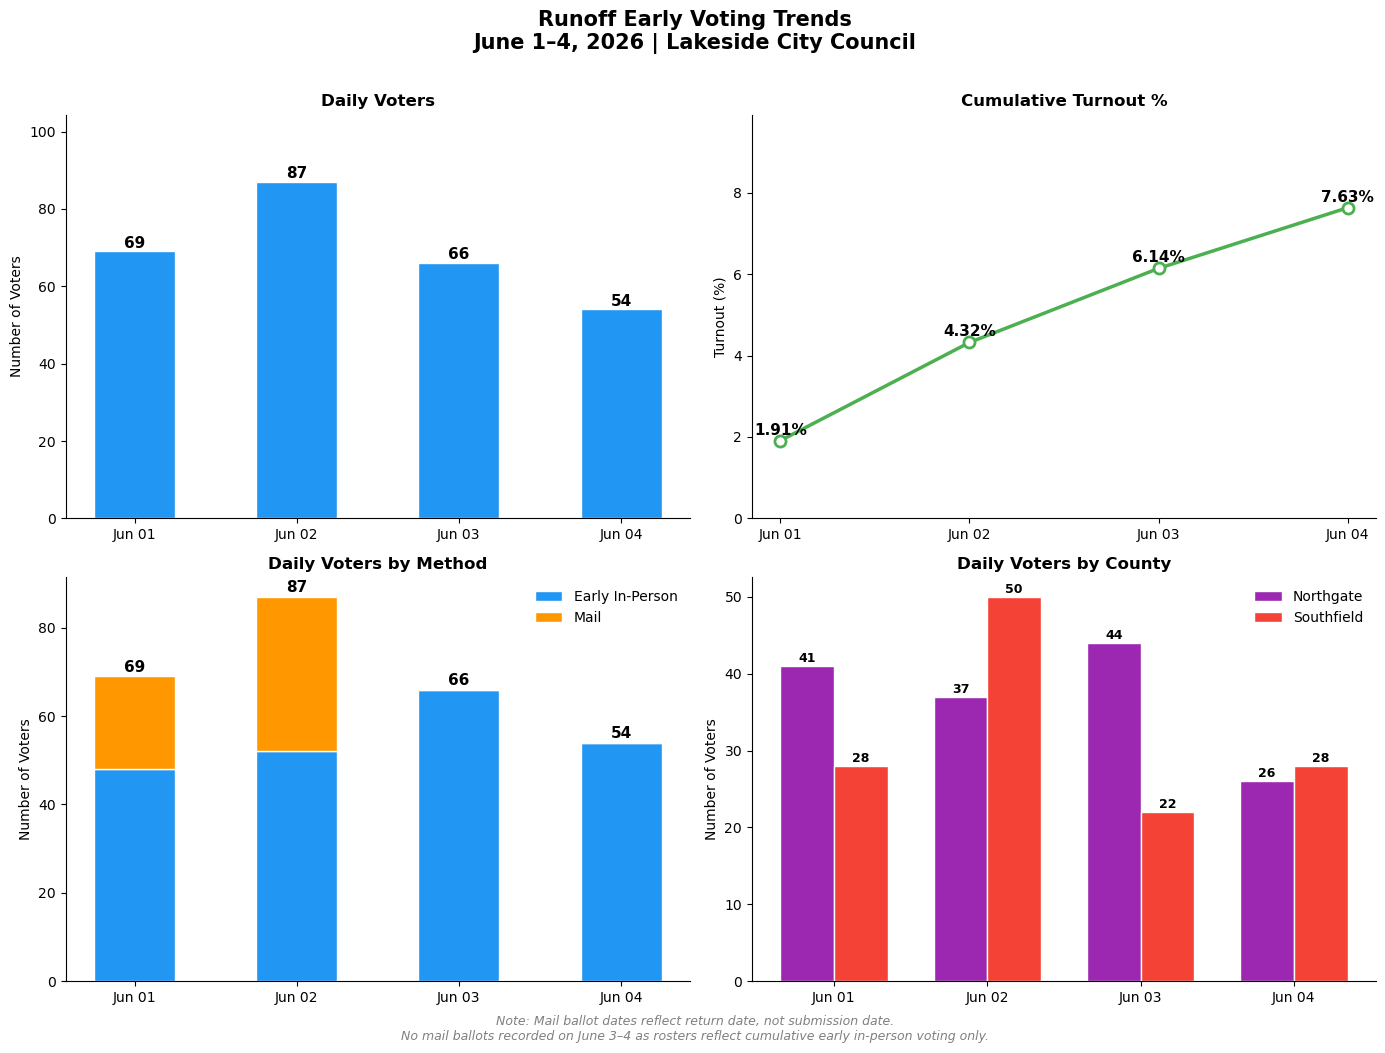

In [75]:
# ── Daily Runoff Turnout Visualization ───────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Runoff Early Voting Trends\nJune 1–4, 2026 | Lakeside City Council",
             fontsize=15, fontweight="bold", y=1.01)

dates = daily_turnout["vote_date"].dt.strftime("%b %d")
x = range(len(dates))

# ── Chart 1: Daily voters per day (bar) ──────────────────────────────────────
axes[0, 0].bar(x, daily_turnout["voters_per_day"], 
               color="#2196F3", edgecolor="white", width=0.5)
axes[0, 0].set_title("Daily Voters", fontweight="bold")
axes[0, 0].set_ylabel("Number of Voters")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(dates)
axes[0, 0].set_ylim(0, daily_turnout["voters_per_day"].max() * 1.2)

for i, v in enumerate(daily_turnout["voters_per_day"]):
    axes[0, 0].text(i, v + 1, str(v), ha="center", 
                    fontweight="bold", fontsize=11)

axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

# ── Chart 2: Cumulative turnout % (line) ─────────────────────────────────────
axes[0, 1].plot(x, daily_turnout["cumulative_turnout_pct"], 
                color="#4CAF50", marker="o", linewidth=2.5,
                markersize=8, markerfacecolor="white", markeredgewidth=2)
axes[0, 1].set_title("Cumulative Turnout %", fontweight="bold")
axes[0, 1].set_ylabel("Turnout (%)")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(dates)
axes[0, 1].set_ylim(0, daily_turnout["cumulative_turnout_pct"].max() * 1.3)

for i, v in enumerate(daily_turnout["cumulative_turnout_pct"]):
    axes[0, 1].text(i, v + 0.15, f"{v}%", ha="center",
                    fontweight="bold", fontsize=11)

axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

# ── Chart 3: Daily by vote method (stacked bar) ──────────────────────────────
axes[1, 0].bar(x, daily_by_method["early_inperson"],
               color="#2196F3", edgecolor="white", 
               width=0.5, label="Early In-Person")
axes[1, 0].bar(x, daily_by_method["mail"],
               bottom=daily_by_method["early_inperson"],
               color="#FF9800", edgecolor="white",
               width=0.5, label="Mail")
axes[1, 0].set_title("Daily Voters by Method", fontweight="bold")
axes[1, 0].set_ylabel("Number of Voters")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(dates)
axes[1, 0].legend(loc="upper right", frameon=False)

# Add total labels on top
totals = daily_by_method["early_inperson"] + daily_by_method["mail"]
for i, v in enumerate(totals):
    axes[1, 0].text(i, v + 1, str(v), ha="center",
                    fontweight="bold", fontsize=11)

axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)

# ── Chart 4: Daily by county (grouped bar) ───────────────────────────────────
width = 0.35
x_arr = np.arange(len(dates))

axes[1, 1].bar(x_arr - width/2, daily_by_county["Northgate"],
               width=width, color="#9C27B0", 
               edgecolor="white", label="Northgate")
axes[1, 1].bar(x_arr + width/2, daily_by_county["Southfield"],
               width=width, color="#F44336",
               edgecolor="white", label="Southfield")
axes[1, 1].set_title("Daily Voters by County", fontweight="bold")
axes[1, 1].set_ylabel("Number of Voters")
axes[1, 1].set_xticks(x_arr)
axes[1, 1].set_xticklabels(dates)
axes[1, 1].legend(loc="upper right", frameon=False)

# Add value labels
for i, (n, s) in enumerate(zip(daily_by_county["Northgate"], 
                                daily_by_county["Southfield"])):
    axes[1, 1].text(i - width/2, n + 0.5, str(n), 
                    ha="center", fontsize=9, fontweight="bold")
    axes[1, 1].text(i + width/2, s + 0.5, str(s), 
                    ha="center", fontsize=9, fontweight="bold")

axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)

# ── Footer note ───────────────────────────────────────────────────────────────
fig.text(0.5, -0.02,
         "Note: Mail ballot dates reflect return date, not submission date.\n"
         "No mail ballots recorded on June 3–4 as rosters reflect cumulative early in-person voting only.",
         ha="center", fontsize=9, color="gray", style="italic")

plt.tight_layout()
plt.savefig("daily_turnout_trend.png", dpi=150, bbox_inches="tight")
plt.show()